<a href="https://colab.research.google.com/github/Sebastian-Tamez/PDI_Laboratorio/blob/main/P7_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICA 7**

Para empezar, se cargan las librerias necesarias para el ejercicio.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

Después se carga la imagen especificada en las instrucciones.

In [6]:
img = cv2.imread('Te-me_0015.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Se separan los canales por colores RGB.

In [7]:
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

La imagen es convertida a escala de grises usando un promedio simple y se aplica una segmentación simple, obteniendo como resultado una imagen binaria.

In [8]:
gray_avg = ((R.astype(np.float32) + G + B) / 3).astype(np.uint8)

_, seg_simple = cv2.threshold(gray_avg, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

Ahora se normalizan los canales RGB para después realizar la función de optimización. Se aplican resticciones para que los pesos sumen 1 entre ellos y después se aplica el método SLSQP. Se obtienen los pesos óptimos y se genera una nueva imagen a partir de estos.

In [9]:
R_norm = R.astype(np.float32) / 255
G_norm = G.astype(np.float32) / 255
B_norm = B.astype(np.float32) / 255

def grayscale_variance(weights):
    w_r, w_g, w_b = weights
    gray = w_r * R_norm + w_g * G_norm + w_b * B_norm
    gray_normalized = (gray - gray.min()) / (gray.max() - gray.min())
    return -np.var(gray_normalized)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = [(0, 1), (0, 1), (0, 1)]
initial_weights = [0.33, 0.33, 0.34]

result = minimize(grayscale_variance, initial_weights,
                  method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = result.x
print("Pesos óptimos:", optimal_weights)

# Imagen en escala de grises óptima
gray_optimal = (optimal_weights[0] * R_norm +
                optimal_weights[1] * G_norm +
                optimal_weights[2] * B_norm)

gray_optimal = (gray_optimal * 255).astype(np.uint8)

Pesos óptimos: [0.33 0.33 0.34]


Se aplica otra segmentación ahora sobre la imagen optimizada anteriormente.

In [10]:
_, seg_optimal = cv2.threshold(gray_optimal, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)

Se realiza una limpieza del ruido en la imagen.

In [11]:
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(seg_optimal, cv2.MORPH_OPEN,
                           kernel, iterations=2)

clean = cv2.morphologyEx(opening, cv2.MORPH_CLOSE,
                         kernel, iterations=2)

Ahora, se detectan las regiones conectadas y se ignora el fondo. Después de esto seleccionamos la segunda area más grande la cual corresponde al tumor. Se crea una máscara que solo contiene al tumor.

In [12]:
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean)

# Obtener áreas (sin fondo)
areas = stats[1:, cv2.CC_STAT_AREA]

# Ordenar de mayor a menor
sorted_labels = np.argsort(areas)[::-1]

# Seleccionar el segundo más grande
second_largest_label = 1 + sorted_labels[1]

# Crear máscara del tumor
tumor = np.zeros_like(clean)
tumor[labels == second_largest_label] = 255

Se realiza el calculo del area del tumor.

In [13]:
area = cv2.countNonZero(tumor)
print("Área del tumor en píxeles:", area)

Área del tumor en píxeles: 12956


Finalmente visualizamos todos los resultados de la practica junto con los pesos óptimos y el area del tumor.

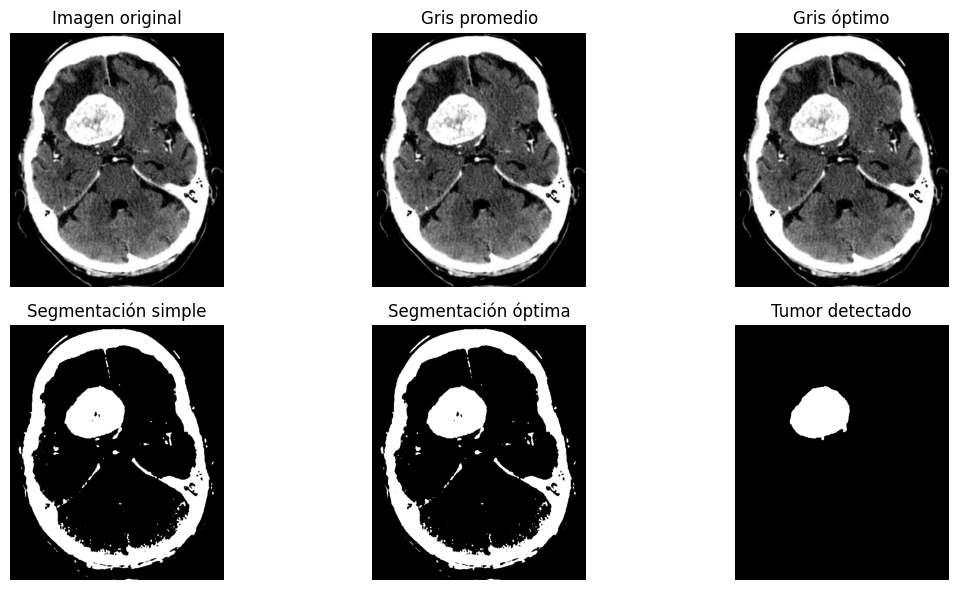

In [14]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gray_avg, cmap='gray')
plt.title("Gris promedio")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(gray_optimal, cmap='gray')
plt.title("Gris óptimo")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(seg_simple, cmap='gray')
plt.title("Segmentación simple")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(seg_optimal, cmap='gray')
plt.title("Segmentación óptima")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(tumor, cmap='gray')
plt.title("Tumor detectado")
plt.axis('off')

plt.tight_layout()
plt.show()